In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import sys

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

utils_path = os.path.abspath(
    os.path.join(os.getcwd(), '..', '2_data_analysis', 'utils')
)
sys.path.append(utils_path)
import plot_style

from functions.hazard_model import run_hazard

# Palette
C_AGR   = '#C0392B'   # red  - with agreement
C_NOAGR = '#2C6E8A'   # blue - without agreement

RESULTS_DIR = '../4_results/survival/'
os.makedirs(RESULTS_DIR, exist_ok=True)

## **Load Data**

---

Loads `spell_q.csv` produced by `proxies_construction.ipynb`. Each row is one **conflict × quarter** observation. Run `proxies_construction.ipynb` first if the file does not exist.

- **Unit of analysis:** conflict × quarter
- **Event:** `is_first_agreement = 1` in the quarter of the first peace agreement
- **Censoring:** `ever_agreement = 0` for conflicts that never sign

In [2]:
spell_q = pd.read_csv('../../data/output/conflict_level/spell_q.csv')
spell_q['yq'] = pd.PeriodIndex(spell_q['yq'], freq='Q')

# Conflict-level summary (reused across descriptive cells)
conflicts_cl = (
    spell_q
    .groupby('conflict_id')
    .agg(
        ever_agreement=('ever_agreement', 'first'),
        duration_q=('conflict_age_q', 'max'),
    )
    .reset_index()
)

print(f'Spell dataset: {len(spell_q):,} conflict-quarters, {spell_q["conflict_id"].nunique()} conflicts')
print(f'Events (first agreement): {spell_q["is_first_agreement"].sum()}')
print(f'Right-censored conflicts: {(conflicts_cl["ever_agreement"]==0).sum()}')

Spell dataset: 6,491 conflict-quarters, 201 conflicts
Events (first agreement): 103
Right-censored conflicts: 98


In [3]:
spell_q

,conflict_id,yq,start_date_q,end_date_q,is_first_agreement,ever_agreement,conflict_age_q,log_conflict_age_q,best,n_events,...,vdem_state_territorial_control_pre5y,vdem_horizontal_accountability_pre5y,vdem_judicial_constraints_pre5y,vdem_legislative_constraints_pre5y,vdem_neopatrimonial_pre5y,vdem_wb_political_stability_pre5y,country,region,isocode,type_of_conflict
0,205,1990Q2,1990-04-01,2022-10-01,0,0,1,0.693147,24.0,8.0,...,92.2668,0.1668,0.1460,0.6012,0.7438,NaN,Iran,Middle East,IRN,interstate
1,205,1990Q3,1990-04-01,2022-10-01,0,0,2,1.098612,7.0,6.0,...,92.2668,0.1668,0.1460,0.6012,0.7438,NaN,Iran,Middle East,IRN,interstate
2,205,1990Q4,1990-04-01,2022-10-01,0,0,3,1.386294,0.0,0.0,...,92.2668,0.1668,0.1460,0.6012,0.7438,NaN,Iran,Middle East,IRN,interstate
3,205,1991Q1,1990-04-01,2022-10-01,0,0,4,1.609438,0.0,1.0,...,92.2002,0.1648,0.1460,0.6098,0.7458,NaN,Iran,Middle East,IRN,interstate
4,205,1991Q2,1990-04-01,2022-10-01,0,0,5,1.791759,0.0,0.0,...,92.2002,0.1648,0.1460,0.6098,0.7458,NaN,Iran,Middle East,IRN,interstate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6486,16292,2019Q1,2018-07-01,2019-10-01,0,0,3,1.386294,0.0,0.0,...,88.7306,-1.5234,0.0354,0.0472,0.9706,-0.6482,Tajikistan,Asia,TJK,interstate
6487,16292,2019Q2,2018-07-01,2019-10-01,0,0,4,1.609438,32.0,1.0,...,88.7306,-1.5234,0.0354,0.0472,0.9706,-0.6482,Tajikistan,Asia,TJK,interstate
6488,16292,2019Q3,2018-07-01,2019-10-01,0,0,5,1.791759,0.0,0.0,...,88.7306,-1.5234,0.0354,0.0472,0.9706,-0.6482,Tajikistan,Asia,TJK,interstate
6489,16292,2019Q4,2018-07-01,2019-10-01,0,0,6,1.945910,17.0,1.0,...,88.7306,-1.5234,0.0354,0.0472,0.9706,-0.6482,Tajikistan,Asia,TJK,interstate


(<Figure size 1500x900 with 1 Axes>,
 <Axes: title={'center': 'Conflict spells — survival analysis risk set'}, xlabel='Year'>)

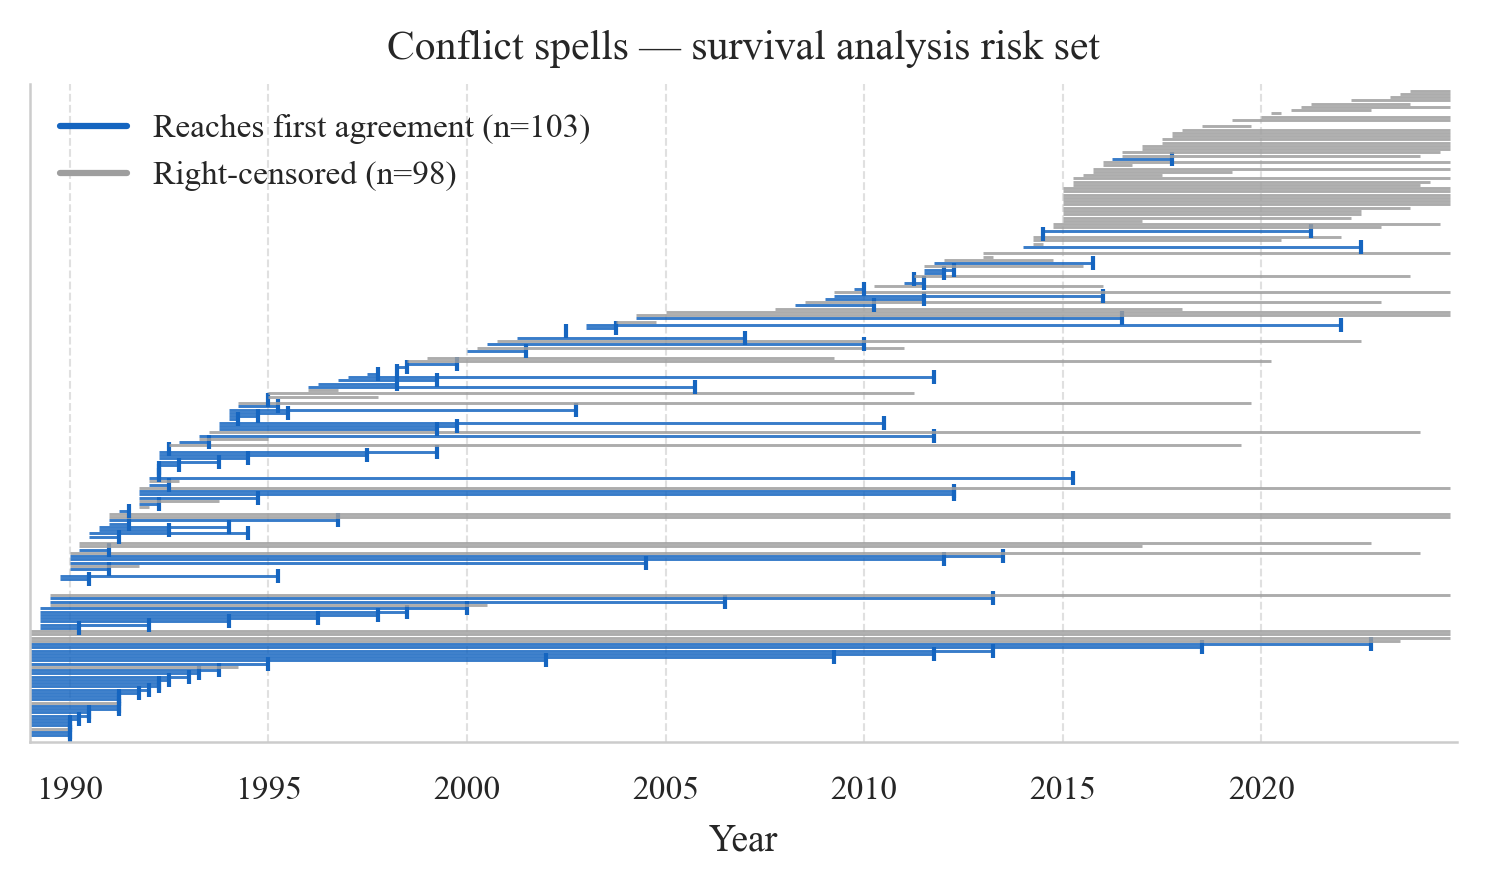

In [4]:
#plot the bargaining space
from functions.plot_functions import plot_spell_panel 

plot_spell_panel(spell_q, 
                     start_date_column='start_date_q',
                     end_date_column='end_date_q',
                     period_column='yq',
                     agreement_indicator_column='ever_agreement')

## **Descriptive Statistics**

---

Tables and figures for the survival analysis section of the paper. Figures are saved as PDF to `src/4_results/survival/`; LaTeX table strings are printed for copy-paste.

Requires `\usepackage{booktabs}` in the LaTeX preamble.

In [5]:
def to_latex_table(df, caption, label, col_format=None, float_fmt='.2f'):
    '''Return a LaTeX booktabs table string ready to paste into a .tex file.'''
    ncols = len(df.columns)
    if col_format is None:
        col_format = 'l' + 'c' * (ncols - 1)

    def _fmt(v):
        if isinstance(v, str):
            return v
        try:
            if pd.isna(v):
                return '--'
        except (TypeError, ValueError):
            pass
        if isinstance(v, (float, np.floating)):
            return f'{v:{float_fmt}}'
        return str(v)

    header    = ' & '.join(str(c) for c in df.columns) + ' \\\\'
    data_rows = [
        ' & '.join(_fmt(v) for v in row) + ' \\\\'
        for _, row in df.iterrows()
    ]
    lines = (
        ['\\begin{table}[htbp]', '  \\centering',
         f'  \\caption{{{caption}}}', f'  \\label{{{label}}}',
         f'  \\begin{{tabular}}{{{col_format}}}',
         '  \\toprule', f'  {header}', '  \\midrule']
        + [f'  {r}' for r in data_rows]
        + ['  \\bottomrule', '  \\end{tabular}', '\\end{table}']
    )
    return '\n'.join(lines)

### Table 1 — Conflict-level Survival Summary

In [6]:
n_total  = len(conflicts_cl)
n_signed = int(conflicts_cl['ever_agreement'].sum())
n_cens   = n_total - n_signed
dur_agr  = conflicts_cl.loc[conflicts_cl['ever_agreement'] == 1, 'duration_q']
dur_cens = conflicts_cl.loc[conflicts_cl['ever_agreement'] == 0, 'duration_q']
dur_all  = conflicts_cl['duration_q']

tbl1 = pd.DataFrame([
    ('Total conflicts',                      f'{n_total}'),
    (r'\quad Reach first agreement',         f'{n_signed}'),
    (r'\quad Right-censored',                f'{n_cens}'),
    ('Mean duration to agreement (qtrs.)',   f'{dur_agr.mean():.1f}'),
    ('Median duration to agreement (qtrs.)', f'{dur_agr.median():.0f}'),
    ('Mean duration, censored (qtrs.)',      f'{dur_cens.mean():.1f}'),
    ('p25 observed duration (qtrs.)',        f'{dur_all.quantile(.25):.0f}'),
    ('p50 observed duration (qtrs.)',        f'{dur_all.quantile(.50):.0f}'),
    ('p75 observed duration (qtrs.)',        f'{dur_all.quantile(.75):.0f}'),
    ('p90 observed duration (qtrs.)',        f'{dur_all.quantile(.90):.0f}'),
], columns=['Statistic', 'Value'])

latex1 = to_latex_table(
    tbl1,
    caption='Conflict-level survival summary. Duration measured in quarters.',
    label='tab:survival_summary',
    col_format='lc',
)
print(latex1)

\begin{table}[htbp]
  \centering
  \caption{Conflict-level survival summary. Duration measured in quarters.}
  \label{tab:survival_summary}
  \begin{tabular}{lc}
  \toprule
  Statistic & Value \\
  \midrule
  Total conflicts & 201 \\
  \quad Reach first agreement & 103 \\
  \quad Right-censored & 98 \\
  Mean duration to agreement (qtrs.) & 25.2 \\
  Median duration to agreement (qtrs.) & 11 \\
  Mean duration, censored (qtrs.) & 39.8 \\
  p25 observed duration (qtrs.) & 5 \\
  p50 observed duration (qtrs.) & 17 \\
  p75 observed duration (qtrs.) & 40 \\
  p90 observed duration (qtrs.) & 92 \\
  \bottomrule
  \end{tabular}
\end{table}


### Table 2 — Risk Set by Conflict Age Bin

In [7]:
BINS   = [0, 4, 8, 16, 32, np.inf]
LABELS = ['1--4', '5--8', '9--16', '17--32', '33+']

risk_rows = []
for i, lbl in enumerate(LABELS):
    t_lo = int(BINS[i]) + 1
    t_hi = BINS[i + 1]
    at_risk  = int((conflicts_cl['duration_q'] >= t_lo).sum())
    in_bin   = (conflicts_cl['duration_q'] >= t_lo) & (conflicts_cl['duration_q'] <= t_hi)
    n_events = int((conflicts_cl.loc[in_bin, 'ever_agreement'] == 1).sum())
    n_cens   = int((conflicts_cl.loc[in_bin, 'ever_agreement'] == 0).sum())
    cq       = int(
        ((spell_q['conflict_age_q'] >= t_lo) & (spell_q['conflict_age_q'] <= t_hi)).sum()
    )
    risk_rows.append({
        'Age bin (qtrs.)': lbl,
        'At risk':         at_risk,
        'Conflict-qtrs.':  cq,
        'Agreements':      n_events,
        'Censored exits':  n_cens,
        'Raw hazard':      round(n_events / at_risk, 4) if at_risk > 0 else float('nan'),
    })

tbl2 = pd.DataFrame(risk_rows)
latex2 = to_latex_table(
    tbl2,
    caption=r'Risk set by conflict age bin. Raw hazard = agreements $\div$ conflicts at risk at start of bin.',
    label='tab:risk_set',
    col_format='lrrrrr',
    float_fmt='.4f',
)
print(latex2)

\begin{table}[htbp]
  \centering
  \caption{Risk set by conflict age bin. Raw hazard = agreements $\div$ conflicts at risk at start of bin.}
  \label{tab:risk_set}
  \begin{tabular}{lrrrrr}
  \toprule
  Age bin (qtrs.) & At risk & Conflict-qtrs. & Agreements & Censored exits & Raw hazard \\
  \midrule
  1--4 & 201 & 717 & 27 & 19 & 0.1343 \\
  5--8 & 155 & 575 & 16 & 8 & 0.1032 \\
  9--16 & 131 & 920 & 17 & 11 & 0.1298 \\
  17--32 & 103 & 1414 & 17 & 18 & 0.1650 \\
  33+ & 68 & 2865 & 26 & 42 & 0.3824 \\
  \bottomrule
  \end{tabular}
\end{table}


### Table 3 — Covariate Descriptives

Means and medians split by event quarter (`is_first_agreement = 1`) vs. non-event quarters.

In [8]:
BALANCE_VARS = {
    'conflict_age_q':           'Conflict age (quarters)',
    'best':                     'Fatalities (quarterly)',
    'n_events':                 'Events (quarterly)',
    'initial_ia':               'Information asymmetry index',
    'within_conflict_learning': 'Within-conflict learning',
    'commit_index_tv_q':        'Commitment problem index',
    'cv_deaths_q':              'CoV of deaths',
    'deaths_per_event_q':       'Deaths per event (log)',
}

bal_rows = []
for var, label in BALANCE_VARS.items():
    no_agr = spell_q.loc[spell_q['is_first_agreement'] == 0, var].dropna()
    agr    = spell_q.loc[spell_q['is_first_agreement'] == 1, var].dropna()
    bal_rows.append({
        'Variable':            label,
        'Mean (non-event)':    no_agr.mean(),
        'Median (non-event)':  no_agr.median(),
        'Mean (event qtr.)':   agr.mean(),
        'Median (event qtr.)': agr.median(),
    })

tbl3 = pd.DataFrame(bal_rows)
latex3 = to_latex_table(
    tbl3,
    caption=r'Covariate descriptives: non-event quarters vs.\ event (first-agreement) quarter.',
    label='tab:covariate_balance',
    col_format='lrrrr',
    float_fmt='.3f',
)
print(latex3)

\begin{table}[htbp]
  \centering
  \caption{Covariate descriptives: non-event quarters vs.\ event (first-agreement) quarter.}
  \label{tab:covariate_balance}
  \begin{tabular}{lrrrr}
  \toprule
  Variable & Mean (non-event) & Median (non-event) & Mean (event qtr.) & Median (event qtr.) \\
  \midrule
  Conflict age (quarters) & 38.784 & 28.000 & 25.175 & 11.000 \\
  Fatalities (quarterly) & 140.613 & 2.000 & 656.257 & 10.500 \\
  Events (quarterly) & 11.033 & 1.000 & 22.243 & 3.000 \\
  Information asymmetry index & 0.558 & 0.343 & 0.599 & 0.493 \\
  Within-conflict learning & 54.200 & 18.993 & 31.466 & 14.467 \\
  Commitment problem index & -0.000 & 0.111 & 0.017 & 0.135 \\
  CoV of deaths & 0.526 & 0.433 & 0.696 & 0.591 \\
  Deaths per event (log) & 1.039 & 0.946 & 1.634 & 1.486 \\
  \bottomrule
  \end{tabular}
\end{table}


## **Figures**

---

### Figure 1 — Number at Risk by Conflict Age

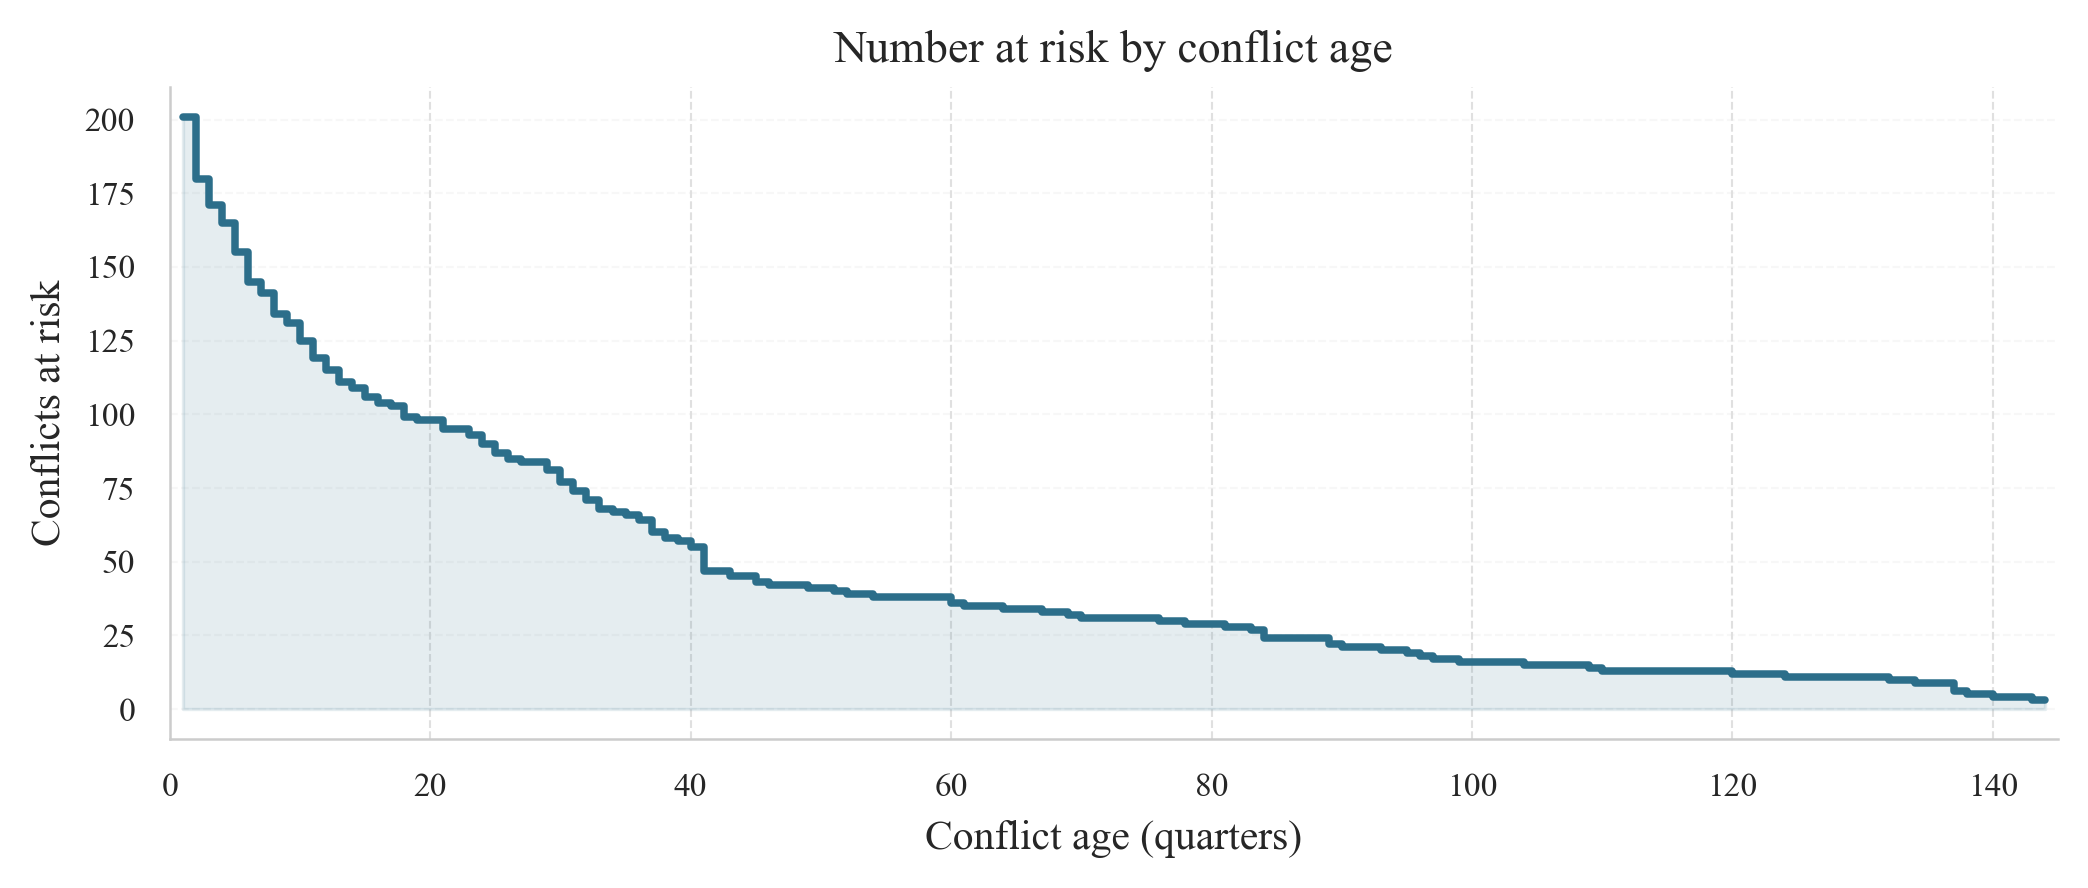

In [9]:
max_q     = int(spell_q['conflict_age_q'].max())
ages      = list(range(1, max_q + 1))
n_at_risk = [(conflicts_cl['duration_q'] >= q).sum() for q in ages]

fig, ax = plt.subplots(figsize=(7, 3))
ax.step(ages, n_at_risk, where='post', color=C_NOAGR, lw=1.8)
ax.fill_between(ages, n_at_risk, step='post', alpha=0.12, color=C_NOAGR)
ax.set_xlabel('Conflict age (quarters)', fontsize=10)
ax.set_ylabel('Conflicts at risk', fontsize=10)
ax.set_title('Number at risk by conflict age', fontsize=11)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max_q + 1)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}fig1_n_at_risk.pdf', bbox_inches='tight')
plt.show()

### Figure 2 — Raw Quarterly Hazard by Conflict Age Bin

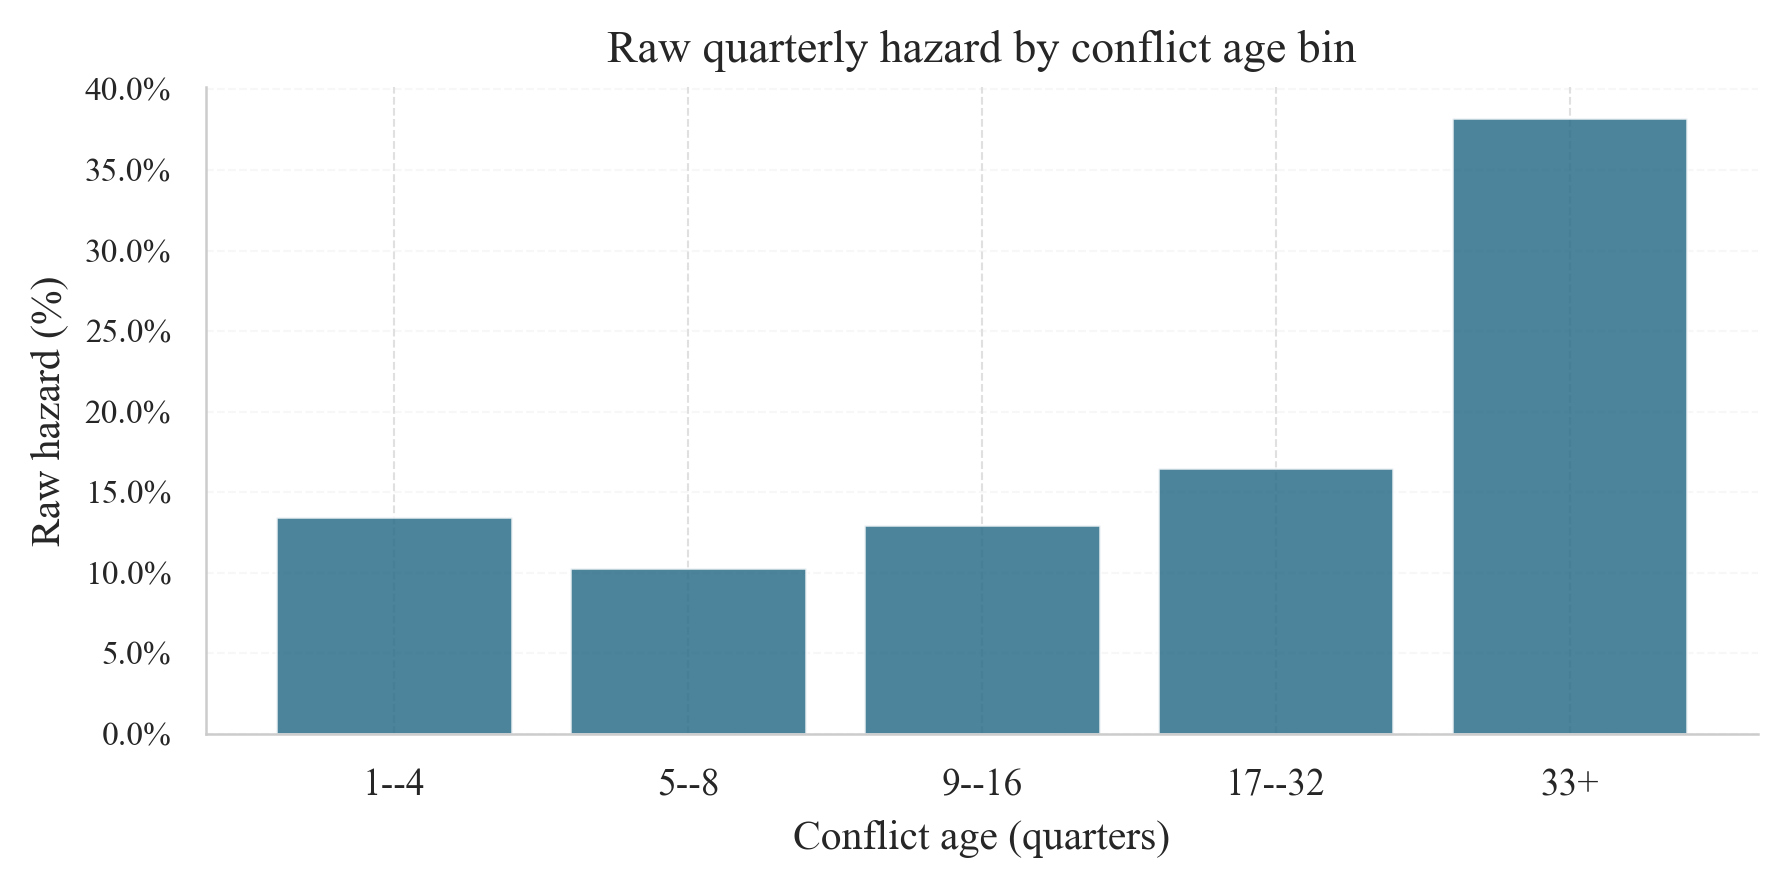

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
x_pos = range(len(tbl2))
ax.bar(
    x_pos, tbl2['Raw hazard'] * 100,
    color=C_NOAGR, alpha=0.85, edgecolor='white', linewidth=0.6,
)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(tbl2['Age bin (qtrs.)'], fontsize=9)
ax.set_xlabel('Conflict age (quarters)', fontsize=10)
ax.set_ylabel('Raw hazard (%)', fontsize=10)
ax.set_title('Raw quarterly hazard by conflict age bin', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}fig2_raw_hazard.pdf', bbox_inches='tight')
plt.show()

### Figure 3 — First Agreements over Calendar Time

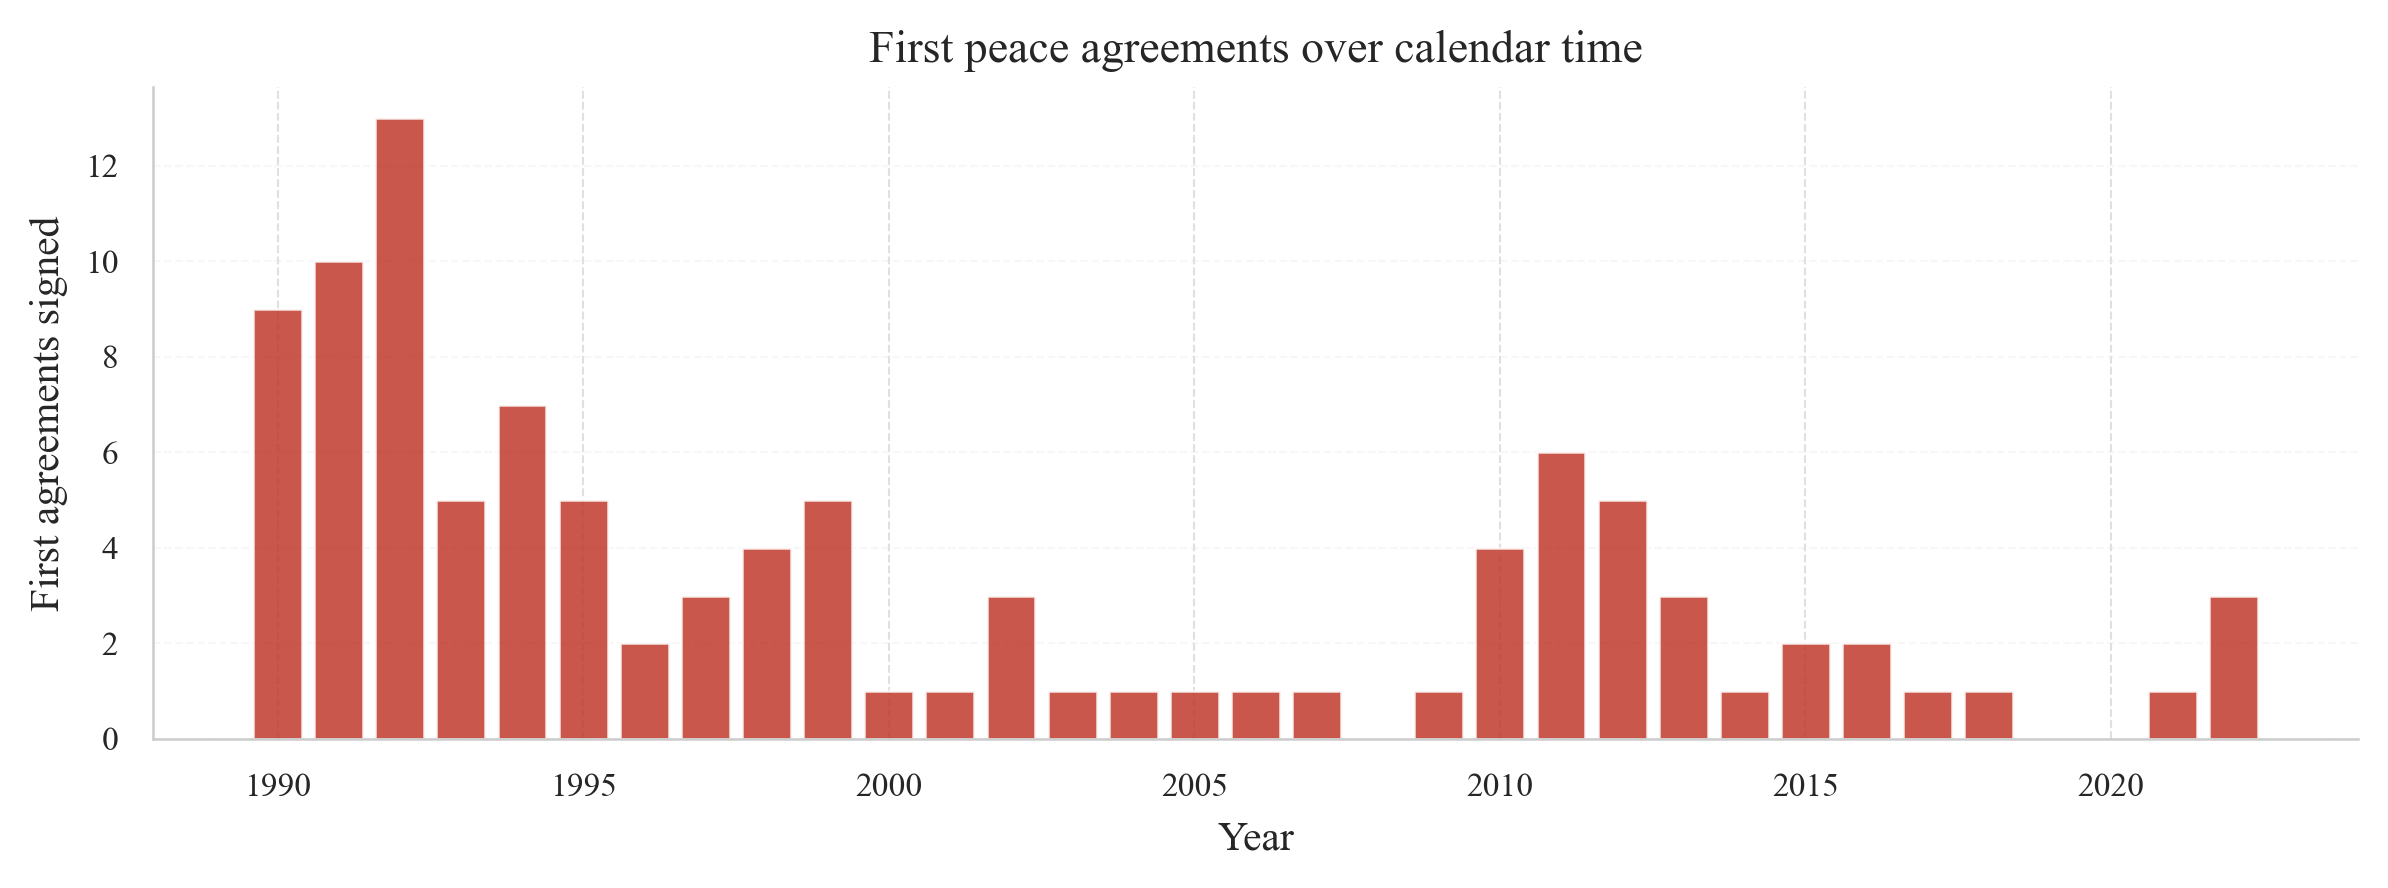

In [11]:
agr_cal = spell_q.loc[spell_q['is_first_agreement'] == 1, ['conflict_id', 'yq']].copy()
agr_cal['year'] = agr_cal['yq'].dt.year
by_year = agr_cal.groupby('year').size().reset_index(name='n')

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(
    by_year['year'], by_year['n'],
    color=C_AGR, alpha=0.85, edgecolor='white', linewidth=0.6, width=0.8,
)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('First agreements signed', fontsize=10)
ax.set_title('First peace agreements over calendar time', fontsize=11)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}fig3_agreements_calendar.pdf', bbox_inches='tight')
plt.show()

## **Kaplan-Meier Survival Curves**

---

Non-parametric estimate of the survival function $S(t) = P(\text{no agreement by quarter } t)$, stratified by information asymmetry level.

- **High IA** (`high_ia_bin = 1`): conflicts with no prior fighting experience between the same parties (`experience_total = 0`). Theory predicts these reach agreement *sooner* once they start fighting.
- **Low IA** (`high_ia_bin = 0`): conflicts with prior experience; parties already have a better read of each other's strength.

The log-rank test checks whether the two curves are statistically different.

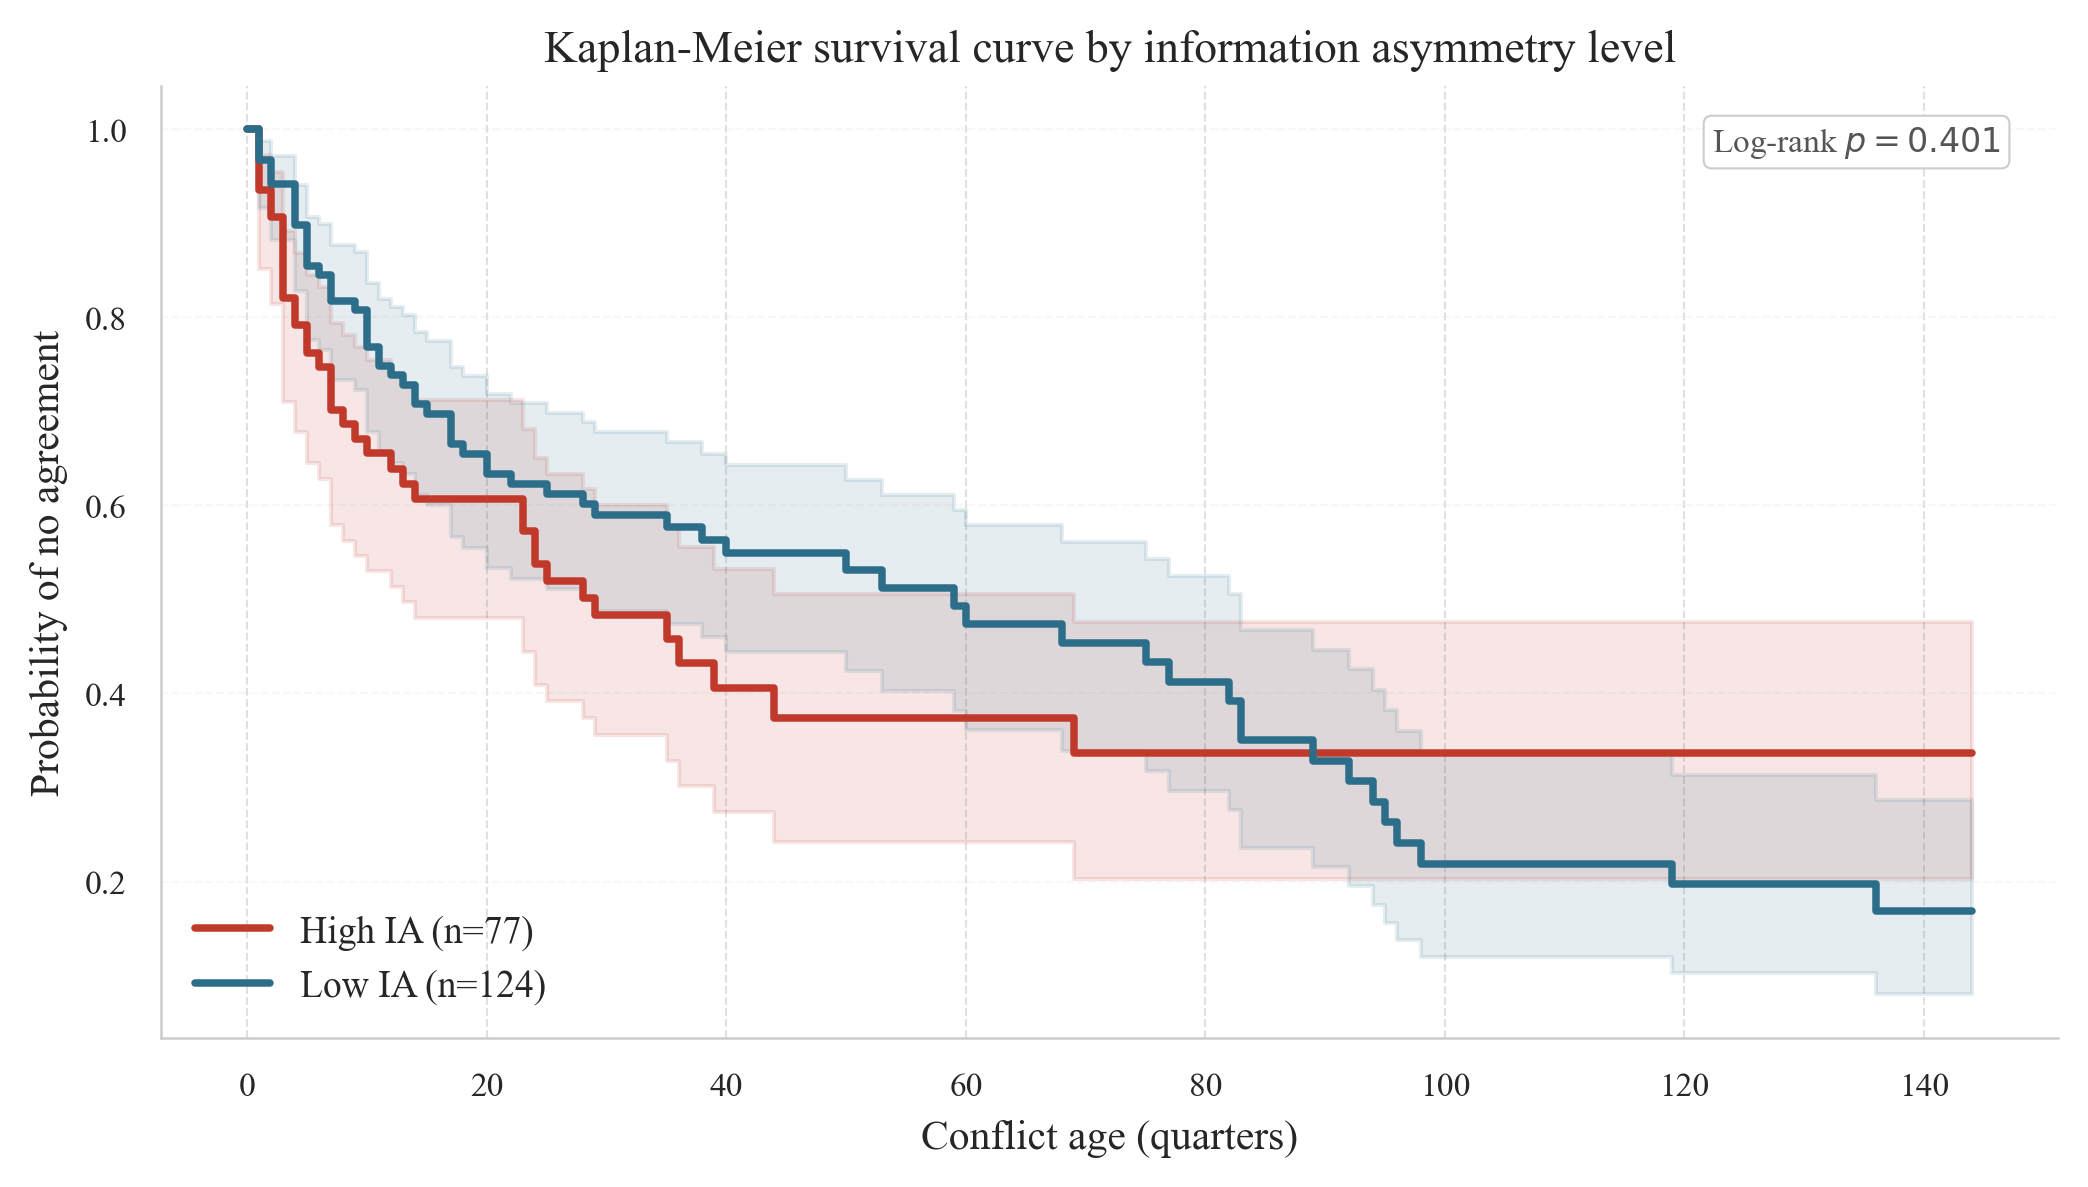

In [12]:
km_data = (
    spell_q
    .groupby('conflict_id')
    .agg(
        duration_q=('conflict_age_q', 'max'),
        event=('ever_agreement', 'first'),
        ia=('high_ia_bin', 'first'),
    )
    .reset_index()
)
mask_hi = km_data['ia'] == 1
mask_lo = ~mask_hi

kmf_hi = KaplanMeierFitter()
kmf_lo = KaplanMeierFitter()
kmf_hi.fit(
    km_data.loc[mask_hi, 'duration_q'], km_data.loc[mask_hi, 'event'],
    label=f'High IA (n={mask_hi.sum()})'
)
kmf_lo.fit(
    km_data.loc[mask_lo, 'duration_q'], km_data.loc[mask_lo, 'event'],
    label=f'Low IA (n={mask_lo.sum()})'
)

fig, ax = plt.subplots(figsize=(7, 4))
kmf_hi.plot_survival_function(ax=ax, color=C_AGR,   lw=1.8, ci_show=True, ci_alpha=0.12)
kmf_lo.plot_survival_function(ax=ax, color=C_NOAGR, lw=1.8, ci_show=True, ci_alpha=0.12)

lr = logrank_test(
    km_data.loc[mask_hi, 'duration_q'], km_data.loc[mask_lo, 'duration_q'],
    km_data.loc[mask_hi, 'event'],      km_data.loc[mask_lo, 'event'],
)
ax.text(
    0.97, 0.96, f'Log-rank $p = {lr.p_value:.3f}$',
    transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#555555',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#cccccc', lw=0.5)
)
ax.set_xlabel('Conflict age (quarters)', fontsize=10)
ax.set_ylabel('Probability of no agreement', fontsize=10)
ax.set_title('Kaplan-Meier survival curve by information asymmetry level', fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}fig4_km_by_ia.pdf', bbox_inches='tight')
plt.show()

## **Discrete-Time Hazard Model (ClogLog)**

---

The complementary log-log (ClogLog) model is the discrete-time analogue of the continuous-time Cox proportional hazard model. At each quarter $t$, the conditional probability that conflict $i$ signs its first agreement is:

$$h_{it} = 1 - \exp\!\left(-\exp(\mathbf{x}_{it}'\boldsymbol{\beta})\right)$$

Exponentiated coefficients are **hazard ratios** (HR):
- HR > 1 → variable *increases* the quarterly probability of signing
- HR < 1 → variable *decreases* the quarterly probability of signing

Standard errors are clustered at the conflict level. 

**Hypothesis H2:** IA-dominant conflicts sign *earlier* (higher hazard), since fighting resolves private information. CP-dominant conflicts sign *later* (lower hazard), since fighting worsens commitment credibility.

In [13]:
from functions.hazard_model import run_hazard, predict_cloglog_ci, plot_hazard_two_panels, run_cox

# ── Load Fearon ethnic fractionalization (static, from Fearon 2003 via QoG) ──
BASE = '../../data/input/fearon_ethnic_fractionalization/'

def load_fe(fname, varname):
    df = pd.read_csv(BASE + fname, index_col=0, sep=';', decimal=',')
    return df.groupby('ccodealp')[varname].first().reset_index()

fe_vars = {
    'fe_etfra':   'qogdata_08_06_2026_fe_etfra.csv',
    'fe_cultdiv': 'qogdata_08_06_2026_fe_cultdiv.csv',
}
spell_q = spell_q.drop(columns=[v for v in fe_vars if v in spell_q.columns], errors='ignore')
spell_q = spell_q.drop(columns='ccodealp', errors='ignore')

for varname, fname in fe_vars.items():
    static = load_fe(fname, varname)
    spell_q = spell_q.merge(static, left_on='isocode', right_on='ccodealp', how='left')
    spell_q = spell_q.drop(columns='ccodealp')

# ── Impute three missing conflicts ────────────────────────────────────────────
# Comoros (COM): not in Fearon 2003 → Africa regional mean
# Serbia (SRB): coded as Yugoslavia → use SDN (Sudan) as proxy for South Sudan (SSD)
# South Sudan (SSD): post-2011 → use Sudan (SDN) value
fe_raw = pd.read_csv(BASE + 'qogdata_08_06_2026_fe_etfra.csv', index_col=0, sep=';', decimal=',')
_val   = lambda c: fe_raw[fe_raw['ccodealp']==c]['fe_etfra'].iloc[0] \
         if c in fe_raw['ccodealp'].values else None

region_lookup = spell_q[['isocode','region']].drop_duplicates()
fe_etfra_u    = fe_raw.groupby('ccodealp')['fe_etfra'].first().reset_index()
reg_mean = (fe_etfra_u.merge(region_lookup, left_on='ccodealp', right_on='isocode', how='left')
            .groupby('region')['fe_etfra'].mean().to_dict())

manual = {k: v for k, v in {'SRB': _val('SCG') or _val('YUG'), 'SSD': _val('SDN')}.items()
          if v is not None}

def _impute(row):
    if pd.notna(row['fe_etfra']): return row['fe_etfra']
    if row['isocode'] in manual:  return manual[row['isocode']]
    return reg_mean.get(row['region'], None)

spell_q['fe_etfra_imp']    = spell_q.apply(_impute, axis=1)
spell_q['high_fe_etfra_bin'] = (spell_q['fe_etfra_imp'] > 0.5).astype(int)
spell_q['year']            = spell_q['yq'].dt.year

print(f"spell_q: {len(spell_q):,} rows | "
      f"{spell_q['conflict_id'].nunique()} conflicts | "
      f"{spell_q['is_first_agreement'].sum()} events")
print(f"fe_etfra_imp NaN after imputation: {spell_q['fe_etfra_imp'].isna().sum()}")
print(f"high_fe_etfra_bin (>0.5): {spell_q['high_fe_etfra_bin'].mean():.1%} of observations")

spell_q: 6,491 rows | 201 conflicts | 103 events
fe_etfra_imp NaN after imputation: 0
high_fe_etfra_bin (>0.5): 74.5% of observations


In [14]:
# ── Spec 1: baseline — duration dependence only ──────────────────────────────
m1, t1 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q',
    spell_q, label='1. Baseline',
)

# ── Spec 2: IA additive ───────────────────────────────────────────────────────
m2, t2 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_ia_bin',
    spell_q, label='2. IA additive',
)

# ── Spec 3: IA × age (main specification for H2) ─────────────────────────────
m3, t3 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_ia_bin'
    ' + log_conflict_age_q:high_ia_bin',
    spell_q, label='3. IA × age',
)

# ── Spec 4: ethnic fractionalization additive (continuous) ────────────────────
m4, t4 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + fe_etfra_imp',
    spell_q, label='4. EF continuous additive',
)

# ── Spec 5: ethnic fractionalization × age (continuous) ──────────────────────
m5, t5 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + fe_etfra_imp'
    ' + log_conflict_age_q:fe_etfra_imp',
    spell_q, label='5. EF continuous × age',
)

# ── Spec 6: ethnic fractionalization binary additive (>0.5) ───────────────────
m6, t6 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_fe_etfra_bin',
    spell_q, label='6. EF binary additive (>0.5)',
)

# ── Spec 7: ethnic fractionalization binary × age (>0.5) ─────────────────────
m7, t7 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_fe_etfra_bin'
    ' + log_conflict_age_q:high_fe_etfra_bin',
    spell_q, label='7. EF binary × age (>0.5)',
)


════════════════════════════════════════════════════════════════════════
  1. Baseline
  Formula : is_first_agreement ~ log_conflict_age_q
  N = 6,491 | Events = 103 | AIC = 1030.5
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_conflict_age_q                         0.616   0.084    0.522    0.727   -5.75   0.000  ***
────────────────────────────────────────────────────────────────────────
  Signif. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
  HR > 1 = faster to agreement  |  HR < 1 = slower to agreement
════════════════════════════════════════════════════════════════════════


════════════════════════════════════════════════════════════════════════
  2. IA additive
  Formula : is_first_agreement ~ log_conflict_age_q + high_ia_bin
  N = 6,491

#### Predicted hazard figures

Left panel (spec 3): IA effect — high vs. low IA over conflict age.
Right panel (spec 7): ethnic fractionalization effect — above vs. below 0.5.
Both panels from their own model; 95% delta-method CI bands; crossover quarter annotated.

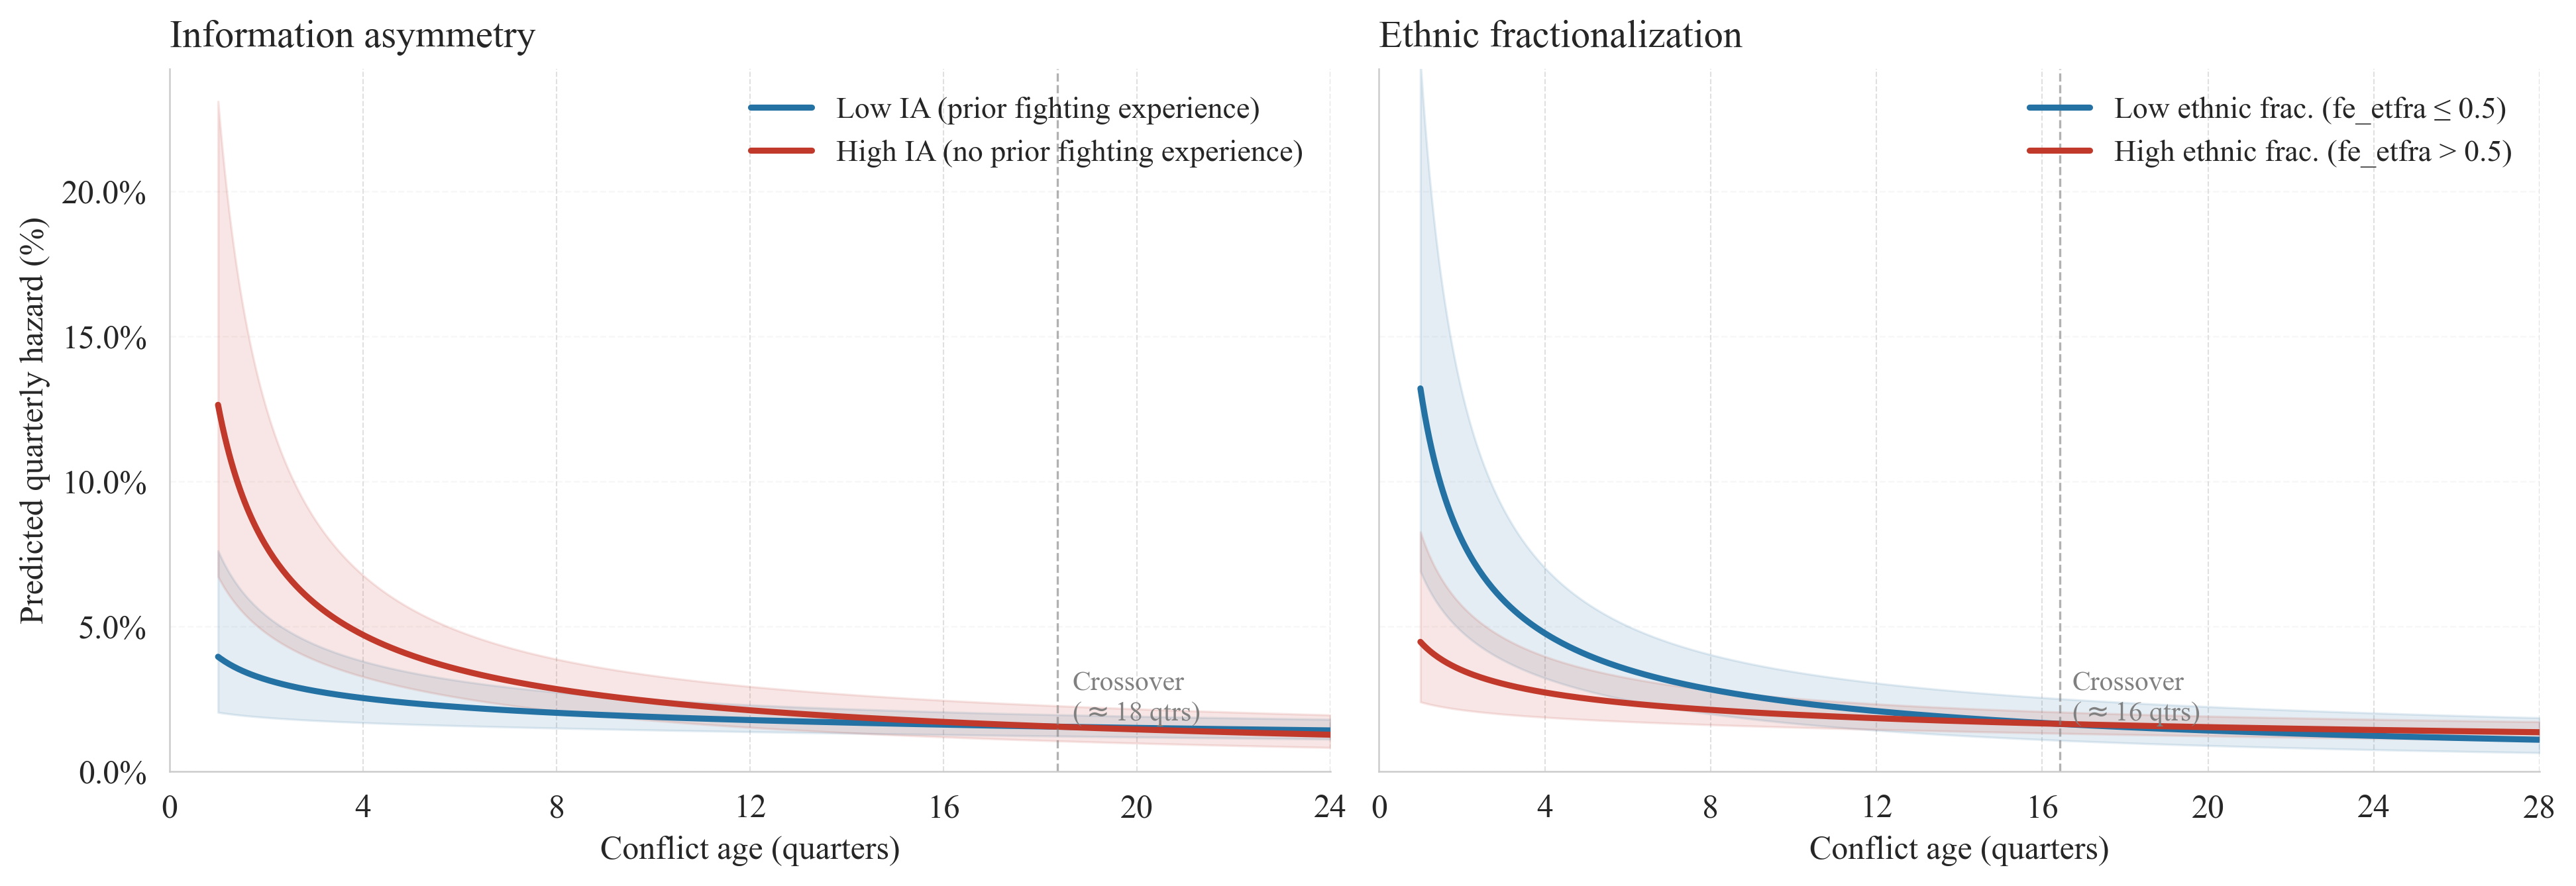

In [15]:
# ── Resolve interaction term names (patsy may reorder) ───────────────────────
IA_INTER = [n for n in m3.model.exog_names
             if 'high_ia_bin' in n and 'log_conflict' in n][0]
EF_INTER = [n for n in m7.model.exog_names
             if 'high_fe_etfra_bin' in n and 'log_conflict' in n][0]

plot_hazard_two_panels(
    model_left  = m3,
    model_right = m7,
    left_main   = 'high_ia_bin',
    left_inter  = IA_INTER,
    right_main  = 'high_fe_etfra_bin',
    right_inter = EF_INTER,
    left_labels  = {0: 'Low IA (prior fighting experience)',
                    1: 'High IA (no prior fighting experience)'},
    right_labels = {0: 'Low ethnic frac. (fe_etfra ≤ 0.5)',
                    1: 'High ethnic frac. (fe_etfra > 0.5)'},
    left_title   = 'Information asymmetry',
    right_title  = 'Ethnic fractionalization',
    age_max_left  = 24,
    age_max_right = 28,
    results_dir  = RESULTS_DIR,
    filename     = 'fig_predicted_hazard_combined.pdf',
)

### Combined specification

Spec 8 includes both information asymmetry and ethnic fractionalization with age interactions,
testing whether both effects survive joint estimation.

In [16]:
# ── Spec 8: IA × age + EF × age ─────────────────────────────────────────────
m8, t8 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q'
    ' + high_ia_bin + log_conflict_age_q:high_ia_bin'
    ' + high_fe_etfra_bin + log_conflict_age_q:high_fe_etfra_bin',
    spell_q, label='8. Combined: IA × age + EF × age',
)


════════════════════════════════════════════════════════════════════════
  8. Combined: IA × age + EF × age
  Formula : is_first_agreement ~ log_conflict_age_q + high_ia_bin + log_conflict_age_q:high_ia_bin + high_fe_etfra_bin + log_conflict_age_q:high_fe_etfra_bin
  N = 6,491 | Events = 103 | AIC = 1028.9
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_conflict_age_q                         0.556   0.191    0.382    0.807   -3.08   0.002  **
  high_ia_bin                                2.923   0.497    1.103    7.746    2.16   0.031  *
  log_conflict_age_q:high_ia_bin             0.698   0.187    0.484    1.007   -1.92   0.054  .
  high_fe_etfra_bin                          0.379   0.493    0.144    0.995   -1.97   0.049  *
  log_conflict_age_q:high_

In [37]:
# ── Spec 1: baseline — duration dependence only ──────────────────────────────
m1, t1 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + C(region)',
    spell_q, label='1. Baseline',
)

# ── Spec 2: IA additive ───────────────────────────────────────────────────────
m2, t2 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_ia_bin + C(region)',
    spell_q, label='2. IA additive',
)

# ── Spec 3: IA × age (main specification for H2) ─────────────────────────────
m3, t3 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_ia_bin + C(region)'
    ' + log_conflict_age_q:high_ia_bin',
    spell_q, label='3. IA × age',
)

# ── Spec 4: ethnic fractionalization additive (continuous) ────────────────────
m4, t4 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + fe_etfra_imp + C(region)',
    spell_q, label='4. EF continuous additive',
)

# ── Spec 5: ethnic fractionalization × age (continuous) ──────────────────────
m5, t5 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + fe_etfra_imp + C(region)'
    ' + log_conflict_age_q:fe_etfra_imp',
    spell_q, label='5. EF continuous × age',
)

# ── Spec 6: ethnic fractionalization binary additive (>0.5) ───────────────────
m6, t6 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_fe_etfra_bin + C(region)',
    spell_q, label='6. EF binary additive (>0.5)',
)

# ── Spec 7: ethnic fractionalization binary × age (>0.5) ─────────────────────
m7, t7 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_fe_etfra_bin + C(region)'
    ' + log_conflict_age_q:high_fe_etfra_bin',
    spell_q, label='7. EF binary × age (>0.5)',
)

# ── Spec 8: IA × age + EF × age ─────────────────────────────────────────────
m8, t8 = run_hazard(
    'is_first_agreement ~ log_conflict_age_q'
    ' + high_ia_bin + log_conflict_age_q:high_ia_bin'
    ' + high_fe_etfra_bin + log_conflict_age_q:high_fe_etfra_bin + C(region)',
    spell_q, label='8. Combined: IA × age + EF × age',
)


════════════════════════════════════════════════════════════════════════
  1. Baseline
  Formula : is_first_agreement ~ log_conflict_age_q + C(region)
  N = 7,631 | Events = 71 | AIC = 750.4
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  C(region)[T.Americas]                      1.858   0.614    0.557    6.190    1.01   0.313  
  C(region)[T.Asia]                          0.729   0.289    0.414    1.285   -1.09   0.275  
  C(region)[T.Europe]                        3.443   0.344    1.754    6.760    3.59   0.000  ***
  C(region)[T.Middle East]                   0.512   0.517    0.186    1.411   -1.29   0.196  
  log_conflict_age_q                         0.556   0.100    0.457    0.677   -5.85   0.000  ***
───────────────────────────────────────────────

In [ ]:
#show me the number of agreements by region
agr_by_region = (
    spell_q
    .loc[spell_q['is_first_agreement'] == 1]
    .groupby('region')
    .size()
    .reset_index(name='n_agreements')
)
print(agr_by_region)

        region  n_agreements
0       Africa            22
1     Americas             5
2         Asia            19
3       Europe            15
4  Middle East             5


In [20]:
#show me the number of agreements by country
agr_by_country = (
    spell_q
    .loc[spell_q['is_first_agreement'] == 1]
    .groupby('country')
    .size()
    .reset_index(name='n_agreements')
)
print(agr_by_country)

                     country  n_agreements
0                Afghanistan             1
1                    Algeria             1
2                     Angola             1
3                 Azerbaijan             1
4         Bosnia-Herzegovina             4
5       Cambodia (Kampuchea)             1
6   Central African Republic             1
7                       Chad             1
8                   Colombia             1
9                      Congo             1
10          DR Congo (Zaire)             1
11               El Salvador             1
12                  Ethiopia             3
13                   Georgia             2
14                 Guatemala             1
15             Guinea-Bissau             1
16                     India             3
17                 Indonesia             2
18                    Israel             1
19               Ivory Coast             1
20                   Lebanon             1
21                   Liberia             1
22         

### Robustness: Extended Cox Proportional Hazards

The ClogLog model parametrizes duration dependence as `β × log_conflict_age_q`. As robustness,
we use an **extended Cox model** where the baseline hazard is estimated non-parametrically.

A simple Cox PH (specs Cox 1, 3) assumes the hazard ratio is **constant across ages** — a
proportional hazards assumption that is violated here: both IA and EF effects erode with age.
Those specs lose significance because they average a large early effect against a small late one.

The extended Cox specs (Cox 2, 4, 5) add `variable × log_age` as a **time-varying covariate**,
allowing non-proportional hazards — the direct Cox equivalent of the ClogLog interaction terms.

In [17]:
# ── Pre-build time-varying interaction terms ─────────────────────────────────
# Cox with time-varying covariates: the interaction IA × log(t) enters as a
# column that changes each quarter — directly comparable to the ClogLog specs.
spell_q['ia_x_log_age']  = spell_q['high_ia_bin']       * spell_q['log_conflict_age_q']
spell_q['ef_x_log_age']  = spell_q['high_fe_etfra_bin'] * spell_q['log_conflict_age_q']

# Cox 1: IA additive — assumes proportional hazards (constant HR across age)
# Equivalent to ClogLog spec 2. Loses significance because PH is violated.
cox1 = run_cox(
    ['high_ia_bin'], spell_q, label='Cox 1: IA additive (PH assumed)',
)

# Cox 2: IA + interaction — extended Cox, allows non-proportional hazards
# Equivalent to ClogLog spec 3. High IA faster early, erodes with age.
cox2 = run_cox(
    ['high_ia_bin', 'ia_x_log_age'], spell_q,
    label='Cox 2: IA × log_age (non-proportional, equiv. spec 3)',
)

# Cox 3: EF additive
cox3 = run_cox(
    ['high_fe_etfra_bin'], spell_q, label='Cox 3: EF binary additive (PH assumed)',
)

# Cox 4: EF + interaction — extended Cox
cox4 = run_cox(
    ['high_fe_etfra_bin', 'ef_x_log_age'], spell_q,
    label='Cox 4: EF × log_age (non-proportional, equiv. spec 7)',
)

# Cox 5: combined — IA + EF both with age interactions
cox5 = run_cox(
    ['high_ia_bin', 'ia_x_log_age', 'high_fe_etfra_bin', 'ef_x_log_age'], spell_q,
    label='Cox 5: combined IA + EF × log_age (equiv. spec 8)',
)


════════════════════════════════════════════════════════════════════════
  Cox 1: IA additive (PH assumed)
  Extended Cox PH | N = 201 conflicts | Events = 66
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  high_ia_bin                                1.243   0.251    0.760    2.031    0.87   0.386  
────────────────────────────────────────────────────────────────────────
  Signif. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
  HR > 1 = faster to agreement  |  HR < 1 = slower to agreement
  Non-parametric baseline; time-varying interaction terms allowed.
════════════════════════════════════════════════════════════════════════


════════════════════════════════════════════════════════════════════════
  Cox 2: IA × log_age (non-proportional, equiv. spec

---
## Appendix

Additional specifications reported in the appendix: UN Security Council voting alignment,
number of active factions, new rebel entry, and external rebel support.

### A1. UN Security Council Voting Alignment

`influence_veto_ihs` measures UNGA voting alignment with P5 veto holders (IHS-transformed).
High alignment → more likely to receive international pressure toward agreement.
Split at median into `high_veto_bin`.

In [18]:
spell_q_unsc  = spell_q.dropna(subset=['influence_veto_ihs']).copy()
_veto_med     = spell_q_unsc['influence_veto_ihs'].median()
spell_q_unsc['high_veto_bin'] = (spell_q_unsc['influence_veto_ihs'] > _veto_med).astype(int)
print(f'UNSC sample: {len(spell_q_unsc):,} rows | '
      f'{spell_q_unsc["is_first_agreement"].sum()} events | '
      f'median veto IHS = {_veto_med:.3f}')

# Additive
m_unsc_add, t_unsc_add = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + influence_veto_ihs',
    spell_q_unsc, label='UNSC continuous additive',
)

# × age (continuous)
m_unsc_cont, t_unsc_cont = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + influence_veto_ihs'
    ' + log_conflict_age_q:influence_veto_ihs',
    spell_q_unsc, label='UNSC continuous × age',
)

# Binary additive
m_unsc_bin, t_unsc_bin = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_veto_bin',
    spell_q_unsc, label='UNSC binary additive',
)

# Binary × age (for figure)
model_unsc, tbl_unsc = run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_veto_bin'
    ' + log_conflict_age_q:high_veto_bin',
    spell_q_unsc, label='UNSC binary × age',
)

# Combined: IA × age + UNSC × age
spell_q_comb = spell_q.dropna(subset=['influence_veto_ihs']).copy()
spell_q_comb['high_veto_bin'] = (spell_q_comb['influence_veto_ihs'] > _veto_med).astype(int)
m_comb, t_comb = run_hazard(
    'is_first_agreement ~ log_conflict_age_q'
    ' + high_ia_bin + log_conflict_age_q:high_ia_bin'
    ' + high_veto_bin + log_conflict_age_q:high_veto_bin',
    spell_q_comb, label='Combined: IA × age + UNSC × age',
)

UNSC sample: 7,631 rows | 66 events | median veto IHS = 4.191

════════════════════════════════════════════════════════════════════════
  UNSC continuous additive
  Formula : is_first_agreement ~ log_conflict_age_q + influence_veto_ihs
  N = 7,631 | Events = 66 | AIC = 695.8
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_conflict_age_q                         0.506   0.099    0.417    0.613   -6.92   0.000  ***
  influence_veto_ihs                         0.674   0.061    0.597    0.760   -6.42   0.000  ***
────────────────────────────────────────────────────────────────────────
  Signif. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
  HR > 1 = faster to agreement  |  HR < 1 = slower to agreement
══════════════════════════════════════════════════

### A2. Multilateral Instability Proxies

- `n_factions_combined` — number of active rebel dyads per conflict-year
- `new_rebel_entry` — new rebel groups entering in a given year
- `rebel_ext_support` — binary indicator of external support to rebels (UCDP ESD, ≤2017 only)

In [19]:
# rebel_ext_support only available through 2017
spell_q_esd = spell_q[spell_q['year'] <= 2017].copy()

# n_factions_combined
run_hazard('is_first_agreement ~ log_conflict_age_q + n_factions_combined',
           spell_q, label='n_factions_combined additive')
run_hazard('is_first_agreement ~ log_conflict_age_q + n_factions_combined'
           ' + n_factions_combined:log_conflict_age_q',
           spell_q, label='n_factions_combined × age')

# new_rebel_entry
run_hazard('is_first_agreement ~ log_conflict_age_q + new_rebel_entry',
           spell_q, label='new_rebel_entry additive')
run_hazard('is_first_agreement ~ log_conflict_age_q + new_rebel_entry'
           ' + new_rebel_entry:log_conflict_age_q',
           spell_q, label='new_rebel_entry × age')

# rebel_ext_support (≤2017 sample)
run_hazard('is_first_agreement ~ log_conflict_age_q + rebel_ext_support',
           spell_q_esd, label='rebel_ext_support additive (≤2017)')
run_hazard('is_first_agreement ~ log_conflict_age_q + rebel_ext_support'
           ' + rebel_ext_support:log_conflict_age_q',
           spell_q_esd, label='rebel_ext_support × age (≤2017)')

# Combined CP proxies
run_hazard(
    'is_first_agreement ~ log_conflict_age_q'
    ' + n_factions_combined + new_rebel_entry + rebel_ext_support',
    spell_q_esd, label='Combined CP proxies (≤2017)',
)


════════════════════════════════════════════════════════════════════════
  n_factions_combined additive
  Formula : is_first_agreement ~ log_conflict_age_q + n_factions_combined
  N = 7,631 | Events = 66 | AIC = 707.6
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_conflict_age_q                         0.488   0.106    0.397    0.601   -6.77   0.000  ***
  n_factions_combined                        1.690   0.139    1.287    2.220    3.77   0.000  ***
────────────────────────────────────────────────────────────────────────
  Signif. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
  HR > 1 = faster to agreement  |  HR < 1 = slower to agreement
════════════════════════════════════════════════════════════════════════


════════════════════════════════

(<statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x11bbd5cd0>,
                         HR     SE  CI_low  CI_high      z      p  sig
 Intercept            0.025  0.359   0.012    0.050 -10.29  0.000  ***
 log_conflict_age_q   0.534  0.103   0.437    0.653  -6.11  0.000  ***
 n_factions_combined  1.183  0.151   0.879    1.591   1.11  0.267     
 new_rebel_entry      1.391  0.227   0.891    2.172   1.45  0.146     
 rebel_ext_support    3.434  0.287   1.959    6.021   4.31  0.000  ***)

### A3. V-Dem Institutional Quality (Commitment Problem Proxies)

V-Dem institutional variables measure state capacity and political constraints **before the conflict started**.
All variables below are **time-invariant**: we use the 5-year pre-conflict rolling mean (`_pre5y`) taken
at the conflict onset year to avoid any data leakage into the spell.

Each variable is **inverted** so that a high score = weaker institutions = more severe commitment problem:
- `cp_state_pre5y` — weak state territorial control (`v2svstterr`)
- `cp_accountability_pre5y` — weak horizontal accountability (`v2x_horacc`)
- `cp_judicial_pre5y` — weak judicial constraints on executive (`v2x_jucon`)
- `cp_legislative_pre5y` — weak legislative constraints on executive (`v2xlg_legcon`)
- `cp_polstab_pre5y` — weak political stability (`e_wbgi_pve`, World Bank)
- `cp_neopat_pre5y` — neopatrimonialism (`v2x_neopat`, used directly; higher = more CP)

A PCA index `cp_index_pre5y` (first principal component, rescaled to [0,1]) combines the first five
variables into a single institutional quality score at the conflict level.

In [20]:
# ── A3 setup: invert pre-computed V-Dem pre5y columns from spell_q ────────────
# Both versions are already in spell_q (exported from 1_proxies_construction.ipynb):
#   _pre5y_start : time-invariant — 5y rolling mean frozen at conflict start year
#   _pre5y       : time-varying   — rolling mean evolves year-by-year during spell
#
# We use _pre5y_start here (recommended for a pre-treatment institutional proxy).
# Invert each variable so that high score = weaker institutions = more severe CP.

spell_q_vdem = spell_q.copy()

spell_q_vdem['cp_state_pre5y']          = -spell_q_vdem['vdem_state_territorial_control_pre5y_start']
spell_q_vdem['cp_accountability_pre5y'] = -spell_q_vdem['vdem_horizontal_accountability_pre5y_start']
spell_q_vdem['cp_judicial_pre5y']       = -spell_q_vdem['vdem_judicial_constraints_pre5y_start']
spell_q_vdem['cp_legislative_pre5y']    = -spell_q_vdem['vdem_legislative_constraints_pre5y_start']
spell_q_vdem['cp_polstab_pre5y']        = -spell_q_vdem['vdem_wb_political_stability_pre5y_start']
spell_q_vdem['cp_neopat_pre5y']         =  spell_q_vdem['vdem_neopatrimonial_pre5y_start']

cp_cols = ['cp_state_pre5y', 'cp_accountability_pre5y', 'cp_judicial_pre5y',
           'cp_legislative_pre5y', 'cp_polstab_pre5y', 'cp_neopat_pre5y']

print(f"spell_q_vdem: {len(spell_q_vdem):,} rows | "
      f"{spell_q_vdem['conflict_id'].nunique()} conflicts")
print("Coverage (non-NaN) per CP variable:")
print(spell_q_vdem[cp_cols].notna().sum())

spell_q_vdem: 7,631 rows | 201 conflicts
Coverage (non-NaN) per CP variable:
cp_state_pre5y             7631
cp_accountability_pre5y    7631
cp_judicial_pre5y          7631
cp_legislative_pre5y       7631
cp_polstab_pre5y           7513
cp_neopat_pre5y            7631
dtype: int64


In [21]:
# ── A3 individual V-Dem CP variable specs ─────────────────────────────────────
CP_VARS = {
    'cp_state_pre5y':          'Weak state (territorial control)',
    'cp_accountability_pre5y': 'Weak horizontal accountability',
    'cp_judicial_pre5y':       'Weak judicial constraints',
    'cp_legislative_pre5y':    'Weak legislative constraints',
    'cp_polstab_pre5y':        'Weak political stability (WB)',
    'cp_neopat_pre5y':         'Neopatrimonialism',
}

for var, label in CP_VARS.items():
    sub = spell_q_vdem.dropna(subset=[var]).copy()
    run_hazard(
        f'is_first_agreement ~ log_conflict_age_q + {var}',
        sub, label=f'{label} — additive',
    )
    run_hazard(
        f'is_first_agreement ~ log_conflict_age_q + {var}'
        f' + {var}:log_conflict_age_q',
        sub, label=f'{label} — × age',
    )


════════════════════════════════════════════════════════════════════════
  Weak state (territorial control) — additive
  Formula : is_first_agreement ~ log_conflict_age_q + cp_state_pre5y
  N = 7,631 | Events = 66 | AIC = 713.6
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_conflict_age_q                         0.484   0.104    0.395    0.594   -6.98   0.000  ***
  cp_state_pre5y                             1.014   0.011    0.993    1.035    1.30   0.194  
────────────────────────────────────────────────────────────────────────
  Signif. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
  HR > 1 = faster to agreement  |  HR < 1 = slower to agreement
════════════════════════════════════════════════════════════════════════


═════════════════════════

In [22]:
# ── A3 combined PCA index of V-Dem CP proxies ─────────────────────────────────
# cp_polstab_pre5y (WB political stability) is excluded from PCA: WB governance
# data starts in 1996, so ~55% of conflicts need imputed values — too many to
# anchor a principal component. It is still tested in the individual specs above.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cp_pca_vars = [
    'cp_state_pre5y',
    'cp_accountability_pre5y',
    'cp_judicial_pre5y',
    'cp_legislative_pre5y',
    'cp_neopat_pre5y',
]

# build index at conflict level (time-invariant: use first row per conflict)
conflict_level = (
    spell_q_vdem
    .groupby('conflict_id')[cp_pca_vars]
    .first()
    .dropna()
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(conflict_level)

pca = PCA(n_components=1)
scores = pca.fit_transform(X_scaled).flatten()

# rescale to [0, 1]
scores = (scores - scores.min()) / (scores.max() - scores.min())
conflict_level['cp_index_pre5y'] = scores

print(f"PCA on {len(conflict_level)} conflicts (5 vars, WB polstab excluded) | "
      f"variance explained: {pca.explained_variance_ratio_[0]:.1%}")
print("Loadings:", dict(zip(cp_pca_vars, pca.components_[0].round(3))))

spell_q_vdem = spell_q_vdem.merge(
    conflict_level[['cp_index_pre5y']].reset_index(),
    on='conflict_id', how='left'
)

med_cp = spell_q_vdem['cp_index_pre5y'].median()
spell_q_vdem['high_cp_bin'] = (spell_q_vdem['cp_index_pre5y'] > med_cp).astype(int)
print(f"Median cp_index_pre5y = {med_cp:.3f} | "
      f"high_cp_bin share = {spell_q_vdem['high_cp_bin'].mean():.1%}")

# 4 specifications: continuous additive, continuous × age, binary additive, binary × age
sub_cp = spell_q_vdem.dropna(subset=['cp_index_pre5y']).copy()

run_hazard(
    'is_first_agreement ~ log_conflict_age_q + cp_index_pre5y',
    sub_cp, label='CP index (continuous) — additive',
)
run_hazard(
    'is_first_agreement ~ log_conflict_age_q + cp_index_pre5y'
    ' + cp_index_pre5y:log_conflict_age_q',
    sub_cp, label='CP index (continuous) — × age',
)
run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_cp_bin',
    sub_cp, label='CP index (binary, median split) — additive',
)
run_hazard(
    'is_first_agreement ~ log_conflict_age_q + high_cp_bin'
    ' + high_cp_bin:log_conflict_age_q',
    sub_cp, label='CP index (binary, median split) — × age',
)

PCA on 201 conflicts (5 vars, WB polstab excluded) | variance explained: 72.2%
Loadings: {'cp_state_pre5y': np.float64(0.199), 'cp_accountability_pre5y': np.float64(0.503), 'cp_judicial_pre5y': np.float64(0.483), 'cp_legislative_pre5y': np.float64(0.475), 'cp_neopat_pre5y': np.float64(0.499)}
Median cp_index_pre5y = 0.660 | high_cp_bin share = 49.7%

════════════════════════════════════════════════════════════════════════
  CP index (continuous) — additive
  Formula : is_first_agreement ~ log_conflict_age_q + cp_index_pre5y
  N = 7,631 | Events = 66 | AIC = 715.3
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_conflict_age_q                         0.479   0.104    0.391    0.587   -7.10   0.000  ***
  cp_index_pre5y                             1.234  

(<statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x11d76d090>,
                                    HR     SE  CI_low  CI_high     z      p  \
 Intercept                       0.075  0.366   0.037    0.154 -7.08  0.000   
 log_conflict_age_q              0.476  0.140   0.361    0.626 -5.30  0.000   
 high_cp_bin                     0.930  0.552   0.315    2.744 -0.13  0.895   
 high_cp_bin:log_conflict_age_q  1.017  0.208   0.677    1.528  0.08  0.935   
 
                                 sig  
 Intercept                       ***  
 log_conflict_age_q              ***  
 high_cp_bin                          
 high_cp_bin:log_conflict_age_q       )

### A4. V-Dem Institutional Quality — Time-Varying Specifications

As a robustness check on A3, we re-run the same specifications using the **time-varying**
version of the V-Dem pre5y variables (`_pre5y`, without `_start`). These are 5-year rolling
means that update year-by-year *during the conflict spell*:
- For **treated** conflicts: evolves up to the agreement quarter.
- For **right-censored** conflicts: evolves over the full observed spell.

This allows institutional quality to change during the conflict — relevant if a state
gradually reforms or collapses while fighting continues.

The same inversion applies: high score = weaker institutions = more severe commitment problem.
The combined index (`cp_index_tv`) uses a time-varying standardised mean of 5 CP variables
(WB political stability excluded for coverage, same as A3).

In [23]:
# ── A4 setup: invert time-varying pre5y columns ──────────────────────────────
spell_q_vdem_tv = spell_q.copy()

spell_q_vdem_tv["cp_state_tv"]          = -spell_q_vdem_tv["vdem_state_territorial_control_pre5y"]
spell_q_vdem_tv["cp_accountability_tv"] = -spell_q_vdem_tv["vdem_horizontal_accountability_pre5y"]
spell_q_vdem_tv["cp_judicial_tv"]       = -spell_q_vdem_tv["vdem_judicial_constraints_pre5y"]
spell_q_vdem_tv["cp_legislative_tv"]    = -spell_q_vdem_tv["vdem_legislative_constraints_pre5y"]
spell_q_vdem_tv["cp_polstab_tv"]        = -spell_q_vdem_tv["vdem_wb_political_stability_pre5y"]
spell_q_vdem_tv["cp_neopat_tv"]         =  spell_q_vdem_tv["vdem_neopatrimonial_pre5y"]

cp_tv_cols = ["cp_state_tv", "cp_accountability_tv", "cp_judicial_tv",
              "cp_legislative_tv", "cp_polstab_tv", "cp_neopat_tv"]

print(f"spell_q_vdem_tv: {len(spell_q_vdem_tv):,} rows | "
      f"{spell_q_vdem_tv['conflict_id'].nunique()} conflicts")
print("Coverage (non-NaN) per time-varying CP variable:")
print(spell_q_vdem_tv[cp_tv_cols].notna().sum())

spell_q_vdem_tv: 7,631 rows | 201 conflicts
Coverage (non-NaN) per time-varying CP variable:
cp_state_tv             7631
cp_accountability_tv    7631
cp_judicial_tv          7631
cp_legislative_tv       7003
cp_polstab_tv           6099
cp_neopat_tv            7631
dtype: int64


In [24]:
# ── A4 individual time-varying V-Dem CP specs ────────────────────────────────
CP_TV_VARS_DICT = {
    "cp_state_tv":          "Weak state (territorial control, TV)",
    "cp_accountability_tv": "Weak horizontal accountability (TV)",
    "cp_judicial_tv":       "Weak judicial constraints (TV)",
    "cp_legislative_tv":    "Weak legislative constraints (TV)",
    "cp_polstab_tv":        "Weak political stability WB (TV)",
    "cp_neopat_tv":         "Neopatrimonialism (TV)",
}

for var, label in CP_TV_VARS_DICT.items():
    sub = spell_q_vdem_tv.dropna(subset=[var]).copy()
    run_hazard(
        f"is_first_agreement ~ log_conflict_age_q + {var}",
        sub, label=f"{label} — additive",
    )
    run_hazard(
        f"is_first_agreement ~ log_conflict_age_q + {var}"
        f" + {var}:log_conflict_age_q",
        sub, label=f"{label} — x age",
    )


════════════════════════════════════════════════════════════════════════
  Weak state (territorial control, TV) — additive
  Formula : is_first_agreement ~ log_conflict_age_q + cp_state_tv
  N = 7,631 | Events = 66 | AIC = 709.6
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_conflict_age_q                         0.490   0.107    0.397    0.604   -6.67   0.000  ***
  cp_state_tv                                1.023   0.010    1.004    1.043    2.33   0.020  *
────────────────────────────────────────────────────────────────────────
  Signif. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
  HR > 1 = faster to agreement  |  HR < 1 = slower to agreement
════════════════════════════════════════════════════════════════════════


═══════════════════════

In [25]:
# ── A4 combined time-varying CP index ────────────────────────────────────────
# Standardise each variable across all conflict-quarter observations (z-score),
# then average the 5 CP variables (WB polstab excluded).
# This gives a time-varying index that evolves within each conflict spell.
from sklearn.preprocessing import StandardScaler

cp_pca_tv = ["cp_state_tv", "cp_accountability_tv", "cp_judicial_tv",
             "cp_legislative_tv", "cp_neopat_tv"]

sub_tv = spell_q_vdem_tv.dropna(subset=cp_pca_tv).copy()

scaler_tv = StandardScaler()
sub_tv["cp_index_tv"] = scaler_tv.fit_transform(sub_tv[cp_pca_tv]).mean(axis=1)

med_tv = sub_tv["cp_index_tv"].median()
sub_tv["high_cp_tv_bin"] = (sub_tv["cp_index_tv"] > med_tv).astype(int)
print(f"Time-varying CP index | {sub_tv['conflict_id'].nunique()} conflicts | "
      f"median = {med_tv:.3f} | high share = {sub_tv['high_cp_tv_bin'].mean():.1%}")

run_hazard(
    "is_first_agreement ~ log_conflict_age_q + cp_index_tv",
    sub_tv, label="CP index TV (continuous) — additive",
)
run_hazard(
    "is_first_agreement ~ log_conflict_age_q + cp_index_tv"
    " + cp_index_tv:log_conflict_age_q",
    sub_tv, label="CP index TV (continuous) — x age",
)
run_hazard(
    "is_first_agreement ~ log_conflict_age_q + high_cp_tv_bin",
    sub_tv, label="CP index TV (binary, median) — additive",
)
run_hazard(
    "is_first_agreement ~ log_conflict_age_q + high_cp_tv_bin"
    " + high_cp_tv_bin:log_conflict_age_q",
    sub_tv, label="CP index TV (binary, median) — x age",
)

Time-varying CP index | 200 conflicts | median = 0.048 | high share = 50.0%

════════════════════════════════════════════════════════════════════════
  CP index TV (continuous) — additive
  Formula : is_first_agreement ~ log_conflict_age_q + cp_index_tv
  N = 7,003 | Events = 66 | AIC = 704.2
  Clustered SE at conflict_id level
────────────────────────────────────────────────────────────────────────
  Variable                                      HR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_conflict_age_q                         0.506   0.105    0.411    0.622   -6.47   0.000  ***
  cp_index_tv                                1.292   0.148    0.967    1.727    1.74   0.083  .
────────────────────────────────────────────────────────────────────────
  Signif. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
  HR > 1 = faster to agreement  |  HR < 1 = slower to agreement
══════════════════════════════════

(<statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x11d7a9550>,
                                       HR     SE  CI_low  CI_high     z      p  \
 Intercept                          0.055  0.417   0.024    0.124 -6.96  0.000   
 log_conflict_age_q                 0.488  0.150   0.364    0.654 -4.80  0.000   
 high_cp_tv_bin                     1.451  0.552   0.492    4.279  0.67  0.500   
 high_cp_tv_bin:log_conflict_age_q  1.056  0.201   0.712    1.567  0.27  0.785   
 
                                    sig  
 Intercept                          ***  
 log_conflict_age_q                 ***  
 high_cp_tv_bin                          
 high_cp_tv_bin:log_conflict_age_q       )

In [26]:
nsa = pd.read_csv(
    '../../data/input/nsa/nsa_v3.4_21November2013.asc',
    sep='\t',
    encoding='latin-1',
    engine='python',
    on_bad_lines='skip'
)

In [27]:
nsa_conflict_id = nsa.ucdpid.astype(int).nunique()
spell_q_conflict_id = spell_q['conflict_id'].astype(int).nunique()
print(f"NSA conflicts: {nsa_conflict_id:,} | spell_q conflicts: {spell_q_conflict_id:,}")
set(nsa['ucdpid'].unique()) - set(spell_q['conflict_id'].unique())

NSA conflicts: 204 | spell_q conflicts: 201


{np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(29),
 np.int64(31),
 np.int64(33),
 np.int64(34),
 np.int64(36),
 np.int64(37),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(54),
 np.int64(56),
 np.int64(57),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.int64(68),
 np.int64(69),
 np.int64(70),
 np.int64(72),
 np.int64(73),
 np.int64(74),
 np.int64(76),
 np.int64(78),
 np.int64(80),
 np.int64(82),
 np.int64(83),
 np.int64(85),
 np.

In [28]:
set(spell_q['conflict_id'].unique())-set(nsa['ucdpid'].unique())

{np.int64(230),
 np.int64(231),
 np.int64(233),
 np.int64(234),
 np.int64(260),
 np.int64(274),
 np.int64(275),
 np.int64(277),
 np.int64(283),
 np.int64(287),
 np.int64(288),
 np.int64(289),
 np.int64(291),
 np.int64(292),
 np.int64(294),
 np.int64(297),
 np.int64(298),
 np.int64(299),
 np.int64(300),
 np.int64(303),
 np.int64(307),
 np.int64(308),
 np.int64(309),
 np.int64(313),
 np.int64(314),
 np.int64(315),
 np.int64(316),
 np.int64(322),
 np.int64(325),
 np.int64(326),
 np.int64(327),
 np.int64(329),
 np.int64(330),
 np.int64(331),
 np.int64(332),
 np.int64(333),
 np.int64(335),
 np.int64(336),
 np.int64(337),
 np.int64(338),
 np.int64(341),
 np.int64(342),
 np.int64(343),
 np.int64(347),
 np.int64(351),
 np.int64(352),
 np.int64(353),
 np.int64(354),
 np.int64(358),
 np.int64(360),
 np.int64(362),
 np.int64(363),
 np.int64(364),
 np.int64(365),
 np.int64(366),
 np.int64(367),
 np.int64(368),
 np.int64(369),
 np.int64(370),
 np.int64(371),
 np.int64(372),
 np.int64(373),
 np.int6

In [29]:
your_ids  = set(spell_q['conflict_id'].astype(int).unique())
nsa_ids   = set(nsa['ucdpid'].astype(int).unique())

overlap   = your_ids & nsa_ids
only_you  = your_ids - nsa_ids
only_nsa  = nsa_ids  - your_ids

print(f"Your conflicts:        {len(your_ids)}")
print(f"NSA conflicts:         {len(nsa_ids)}")
print(f"Overlap:               {len(overlap)}  ({len(overlap)/len(your_ids)*100:.1f}% of yours)")
print(f"Your conflicts NOT in NSA: {len(only_you)}")

# Check whether the missing ones are post-2010 (expected, NSA ends ~2010-2013)
conflict_panel = pd.read_csv('../../data/output/conflict_level/conflict_panel.csv')
missing_meta = (
    conflict_panel[conflict_panel['conflict_id'].isin(only_you)]
    .drop_duplicates('conflict_id')[['conflict_id', 'start_date']]
    .assign(start_year=lambda d: pd.to_datetime(d['start_date']).dt.year)
    .sort_values('start_year')
)
print("\nConflicts in YOUR panel but NOT in NSA:")
print(missing_meta.to_string())
print(f"\nStart year distribution of missing:\n{missing_meta['start_year'].describe()}")


Your conflicts:        201
NSA conflicts:         204
Overlap:               18  (9.0% of yours)
Your conflicts NOT in NSA: 183


/var/folders/fz/1mp_qssx1z546qc9z63nq3rm0000gn/T/ipykernel_80280/966658941.py:14: DtypeWarning: Columns (85,86,88,89,92,93,94,97,98,99,100,101,102,103,109) have mixed types. Specify dtype option on import or set low_memory=False.
  conflict_panel = pd.read_csv('../../data/output/conflict_level/conflict_panel.csv')



Conflicts in YOUR panel but NOT in NSA:
       conflict_id start_date  start_year
26784          351    1989-01        1989
18576          315    1989-01        1989
19008          316    1989-01        1989
19440          322    1989-06        1989
20736          327    1989-01        1989
22032          331    1989-06        1989
22464          332    1989-01        1989
22896          333    1989-01        1989
32832          370    1989-12        1989
23760          336    1989-01        1989
24192          337    1989-02        1989
32400          369    1989-01        1989
25056          341    1989-12        1989
25488          342    1989-04        1989
31968          368    1989-12        1989
31536          367    1989-10        1989
31104          366    1989-04        1989
27216          352    1989-01        1989
30672          365    1989-10        1989
28080          354    1989-01        1989
30240          364    1989-01        1989
17712          313    1989-01      

In [30]:
dyadic = pd.read_csv('../../data/input/ucdp/Dyadic_v25_1.csv', low_memory=False)
#print(dyadic[['conflict_id', 'dyad_new_id', 'side_a', 'side_b']].head(10))

# See if dyadic has old IDs that match NSA
common_cols = [c for c in dyadic.columns if 'id' in c.lower() or 'old' in c.lower()]
print(common_cols)

['dyad_id', 'conflict_id', 'side_a', 'side_a_id', 'side_a_2nd', 'side_b', 'side_b_id', 'side_b_2nd']


In [31]:
nsa[['ucdpid', 'dyadid']].drop_duplicates()

,ucdpid,dyadid
0,1,462
1,1,463
2,1,464
3,2,654
4,3,466
...,...,...
573,268,811
574,269,815
575,270,819
576,271,823


In [32]:
dyadic[['conflict_id', 'dyad_id']].drop_duplicates()

,conflict_id,dyad_id
0,11447,10006
1,372,10054
2,283,10509
6,383,10516
7,13646,10589
...,...,...
3410,437,904
3412,439,906
3419,440,907
3429,395,908
